# Starter Notebook: Qwen 2B LoRA for Text-to-SVG (Kaggle)

This starter is built from the resources in `contest_docs`:
- Data resources: `contest_docs/03_Data_Design.md`
- Baseline and starter guidance: `contest_docs/05_Baselines_and_Starter_Notebooks.md`
- Kaggle implementation notes: `contest_docs/06_Kaggle_Implementation_Guide.md`

Goal: provide a practical scaffold for Qwen-2B-class fine-tuning + submission generation.

## Referenced Data and Docs

### Dataset resources from `contest_docs/03_Data_Design.md`
- `OmniSVG/MMSVG-Icon`
- `xingxm/SVGX-Core-250k`
- `xingxm/SVGX-SFT-1M` (recommended subset: `SVGX_SFT_GEN_51k.json`)
- `nyuuzyou/svgfind`
- `starvector/svg-icons`
- `thesantatitan/deepseek-svg-dataset`
- `InternSVG/SArena` (evaluation benchmark)

### Qwen 2B fine-tuning references from `contest_docs/05` and `contest_docs/06`
- Unsloth Qwen fine-tune docs: https://unsloth.ai/docs/models/qwen3.5/fine-tune
- Qwen3.5-2B Vision notebook: https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_5_(2B)_Vision.ipynb

Note: this notebook is written as a reusable starter. You may need to adjust exact model IDs and column names to match the latest upstream datasets.

In [1]:
!ls "/content/drive/MyDrive/Colab Notebooks/DL/dataset" # WZ
# !ls "/content/drive/MyDrive/Colab_Notebooks/DL/dataset" #WMZ2007

ls: cannot access '/content/drive/MyDrive/Colab Notebooks/DL/dataset': No such file or directory


In [2]:
from google.colab import drive
drive.mount('/content/drive')
# Get kaggle data stored in google drive, not able to implement Kaggle API key in colab


Mounted at /content/drive


In [3]:
# WZ
!cp -r "/content/drive/MyDrive/Colab_Notebooks/DL/dataset" "/content/"
# WMZ2007
# !cp -r "/content/drive/MyDrive/Colab Notebooks/DL/dataset" "/content/"

In [4]:
# Uncomment in a fresh Kaggle notebook environment.
%pip install -q unsloth datasets trl transformers accelerate peft bitsandbytes pandas lxml cairosvg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 145.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 142.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185

In [5]:
import os
import re
import time
import random
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import torch

from datasets import concatenate_datasets, load_dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Torch: 2.10.0+cu128
CUDA available: True


In [6]:
# Core training config.
# Keep runtime targets in line with contest_docs guidance (roughly <= 6-8 hours training).
CONFIG = {
    # "model_name": "unsloth/Qwen3.5-2B-Instruct-bnb-4bit",  # Verify exact ID from the linked Unsloth notebook.
    "model_name": "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit",  # Verify exact ID from the linked Unsloth notebook.
    # https://huggingface.co/unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit
    # "max_seq_length": 5000,
    "max_seq_length": 2048,
    "lora_r": 16,
    "lora_alpha": 16,
    "learning_rate": 2e-4,
    "num_train_epochs": 3,
    "per_device_train_batch_size": 10,
    "gradient_accumulation_steps": 8,
    "warmup_ratio": 0.05,
    "weight_decay": 0.01,
    "logging_steps": 20,
    "eval_steps": 100,
    "save_steps": 200,
    "max_train_samples_per_source": 12000,
    "eval_size": 0.02,
    # TODO: MODIFY DIR, CHANGE SAVE OUTPUT LATTER
    # "output_dir": "/kaggle/working/qwen2b_svg_lora",
    "output_dir": "/content/qwen2b_svg_lora_ABLATION_NONE",
    "param_module" : "NONE"
}
# "q_proj", "k_proj", "v_proj", "o_proj",
# "gate_proj", "up_proj", "down_proj",



In [7]:
import subprocess
subprocess.run(['mkdir', '-p', CONFIG['output_dir']])

CompletedProcess(args=['mkdir', '-p', '/content/qwen2b_svg_lora_ABLATION_NONE'], returncode=0)

In [8]:
def _pick_first_non_empty(example, keys):
    for key in keys:
        if key in example and example[key] is not None:
            val = str(example[key]).strip()
            if val:
                return val
    return ""


def to_prompt_svg(example, prompt_fields, svg_fields):
    prompt = _pick_first_non_empty(example, prompt_fields)
    svg = _pick_first_non_empty(example, svg_fields)
    if not svg.lower().startswith("<svg"):
        return {"prompt": "", "svg": ""}
    return {"prompt": prompt, "svg": svg}


def load_source_dataset(dataset_id, cfg, max_samples):
    print(f"Loading {dataset_id} ...")
    ds = load_dataset(dataset_id, split=cfg["split"])
    if max_samples and len(ds) > max_samples:
        ds = ds.shuffle(seed=SEED).select(range(max_samples))
    ds = ds.map(
        lambda ex: to_prompt_svg(ex, cfg["prompt_fields"], cfg["svg_fields"]),
        remove_columns=ds.column_names,
        desc=f"normalizing {dataset_id}",
    )
    ds = ds.filter(lambda x: bool(x["prompt"]) and bool(x["svg"]))
    print(f"{dataset_id}: {len(ds)} usable rows")
    return ds

In [9]:
from google.colab import userdata
from huggingface_hub import login

# Get the token from Colab secrets
HF_TOKEN = userdata.get('HF_TOKEN')

# Log in to Hugging Face
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("Token is not set. Please save the token first.")


Successfully logged in to Hugging Face!


In [10]:
# MY DATA LOADING

# def format_svg_sample(prompt: str, svg_code: str) -> str:
#     """Format a prompt-SVG pair into the chat template expected by the model."""
#     messages = [
#         {"role": "system", "content": "You are an expert SVG code generator. Generate clean, valid SVG code based on the user's description."},
#         {"role": "user", "content": prompt},
#         {"role": "assistant", "content": svg_code},
#     ]
#     return tokenizer.apply_chat_template(messages, tokenize=False)

# new_prompt = []
# for r in tqdm(range(train_df.shape[0])):
#     new_prompt.append(format_svg_sample(train_df.loc[r, 'prompt'], train_df.loc[r, 'svg']))
# train_df['text'] = new_prompt

# import pandas as pd
# from tqdm import tqdm
from pathlib import Path

# DATA = Path('./dataset')
DATA = Path('/content/dataset')
# train_df = pd.read_csv(DATA / 'train.csv')
# train_df = pd.read_csv(DATA / 'final_df.csv')
train_df = pd.read_csv(DATA / 'Ablation_token_len_final_1700_combined_df.csv')
# NOTE: DATA LIMIT SUBSET
train_df = train_df.sample(10000, random_state=SEED)


from datasets import Dataset
from datasets import load_dataset

# train_dataset = load_dataset("csv", data_files=str(DATA / "train.csv"))
train_dataset = Dataset.from_pandas(train_df)
train_dataset

Dataset({
    features: ['Unnamed: 0', 'id', 'prompt', 'svg', '__index_level_0__'],
    num_rows: 10000
})

In [11]:
# datasets_ok = []
# for source in ACTIVE_SOURCES:
#     try:
#         ds = load_source_dataset(
#             source,
#             DATASET_CATALOG[source],
#             CONFIG["max_train_samples_per_source"],
#         )
#         datasets_ok.append(ds)
#     except Exception as e:
#         print(f"Skipping {source}: {type(e).__name__}: {e}")

# if not datasets_ok:
#     raise RuntimeError("No dataset loaded. Check dataset IDs, internet access, and schema fields.")
# MY DATA

datasets_ok = [train_dataset]

train_raw = datasets_ok[0] if len(datasets_ok) == 1 else concatenate_datasets(datasets_ok)
train_raw = train_raw.shuffle(seed=SEED)

splits = train_raw.train_test_split(test_size=CONFIG["eval_size"], seed=SEED)
train_ds = splits["train"]
eval_ds = splits["test"]

print(f"Train rows: {len(train_ds)}")
print(f"Eval rows: {len(eval_ds)}")
train_ds[0]

Train rows: 9800
Eval rows: 200


{'Unnamed: 0': 71987,
 'id': 'a66d77de410085e3ea1d89b478c6593a',
 'prompt': 'A single purple magnifying glass icon with a circular lens and a handle positioned at the bottom right.',
 'svg': '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#200E32" fill-opacity="1.0"  filling="0" d="M96.7666015625 16.666603088378906 C141.0 16.666603088378906 176.8583984375 51.7333984375 176.8583984375 95.0 C176.8583984375 115.40839385986328 168.875 134.0 155.79159545898438 147.9416046142578 L181.52499389648438 173.02499389648438 C183.93341064453125 175.38339233398438 183.9416046142578 179.20001220703125 181.52499389648438 181.5583953857422 A6.274999618530273 6.274999618530273 0.0 0 1 173.5 182.1584014892578 L172.8083953857422 181.5749969482422 L146.77499389648438 156.1833953857422 A80.8916015625 80.8916015625 0.0 0 1 96.7666015625 173.32501220703125 C52.525001525878906 173.32501220703125 16.666603088378906 138.25 16.666603088378906 94.9

In [12]:
SYSTEM_PROMPT = (
    "You generate compact, valid SVG markup from user requests. "
    "Return only SVG code with a single root <svg> element."
)


def format_sft_text(example):
    text = (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}<|im_end|>\n"
        "<|im_start|>user\n"
        f"{example['prompt']}<|im_end|>\n"
        "<|im_start|>assistant\n"
        f"{example['svg']}<|im_end|>"
    )
    return {"text": text}


train_text = train_ds.map(format_sft_text, remove_columns=train_ds.column_names)
eval_text = eval_ds.map(format_sft_text, remove_columns=eval_ds.column_names)

print(train_text.shape)
print(train_text[0].keys())
print(train_text[0]["text"])

Map:   0%|          | 0/9800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

(9800, 1)
dict_keys(['text'])
<|im_start|>system
You generate compact, valid SVG markup from user requests. Return only SVG code with a single root <svg> element.<|im_end|>
<|im_start|>user
A single purple magnifying glass icon with a circular lens and a handle positioned at the bottom right.<|im_end|>
<|im_start|>assistant
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#200E32" fill-opacity="1.0"  filling="0" d="M96.7666015625 16.666603088378906 C141.0 16.666603088378906 176.8583984375 51.7333984375 176.8583984375 95.0 C176.8583984375 115.40839385986328 168.875 134.0 155.79159545898438 147.9416046142578 L181.52499389648438 173.02499389648438 C183.93341064453125 175.38339233398438 183.9416046142578 179.20001220703125 181.52499389648438 181.5583953857422 A6.274999618530273 6.274999618530273 0.0 0 1 173.5 182.1584014892578 L172.8083953857422 181.5749969482422 L146.77499389648438 156.1833953857422 A80.8916015625 80.891601

In [13]:
# # Load Saved Model on Drive
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name="/content/drive/MyDrive/Colab_Notebooks/DL/qwen2b_svg_lora",
#     max_seq_length=CONFIG["max_seq_length"],
#     dtype=None,
#     load_in_4bit=True,
# )


In [14]:
# Or Load New Model Instance
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=CONFIG["model_name"],
    max_seq_length=CONFIG["max_seq_length"],
    dtype=None,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=0,
    bias="none",
    target_modules=[
        "q_proj",
         "k_proj",
         "v_proj",
         "o_proj",
        "gate_proj",
         "up_proj",
         "down_proj",
    ],
        # "q_proj", {"k_proj"}, "v_proj", "o_proj",
        # "gate_proj", "up_proj", "down_proj",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.41G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [15]:
from transformers import TrainingArguments, EarlyStoppingCallback
from trl import SFTTrainer

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_train_epochs"],
    # num_train_epochs=3,
    per_device_train_batch_size=CONFIG["per_device_train_batch_size"],
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"],
    learning_rate=CONFIG["learning_rate"],
    warmup_ratio=CONFIG["warmup_ratio"],
    weight_decay=CONFIG["weight_decay"],
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=CONFIG["logging_steps"],
    # evaluation_strategy="steps",
    eval_strategy="steps",
    eval_steps=CONFIG["eval_steps"],
    save_steps=CONFIG["save_steps"],

    # Early Stopping Implementation
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none",
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine",
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_text,
    eval_dataset=eval_text,
    dataset_text_field="text",
    max_seq_length=CONFIG["max_seq_length"],
    packing=True,
    args=training_args,
    # Early Stopping Implementation
    callbacks=[EarlyStoppingCallback(early_stopping_patience=6)],
)

train_result = trainer.train()
train_result

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/9800 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,800 | Num Epochs = 3 | Total steps = 369
O^O/ \_/ \    Batch size per device = 10 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (10 x 8 x 1) = 80
 "-____-"     Trainable parameters = 17,432,576 of 2,144,964,608 (0.81% trained)


Step,Training Loss,Validation Loss
100,0.461147,0.463926
200,0.421714,0.430223
300,0.413066,0.418351
369,0.406764,0.416874


TrainOutput(global_step=369, training_loss=0.4650099639323992, metrics={'train_runtime': 2000.2317, 'train_samples_per_second': 14.698, 'train_steps_per_second': 0.184, 'total_flos': 3.306007759926067e+17, 'train_loss': 0.4650099639323992, 'epoch': 3.0})

In [16]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)
trainer.save_model(CONFIG["output_dir"])
tokenizer.save_pretrained(CONFIG["output_dir"])

print(f"Saved adapter + tokenizer to: {CONFIG['output_dir']}")

Saved adapter + tokenizer to: /content/qwen2b_svg_lora_ABLATION_NONE


In [17]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Saving Model
# subprocess.run(['cp', '-r', CONFIG['output_dir'], "/content/drive/MyDrive/Colab Notebooks/DL/"]) # WMZ2007
subprocess.run(['cp', '-r', CONFIG['output_dir'], "/content/drive/MyDrive/Colab_Notebooks/DL/"]) # WZ

CompletedProcess(args=['cp', '-r', '/content/qwen2b_svg_lora_ABLATION_NONE', '/content/drive/MyDrive/Colab_Notebooks/DL/'], returncode=0)

In [19]:
# !cp -r "/content/qwen2b_svg_lora" "/content/drive/MyDrive/Colab Notebooks/DL/"


## KAGGLE SUBMISSION

In [20]:
from unsloth import FastLanguageModel

# Loading Model
model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name='/content/drive/MyDrive/Colab Notebooks/DL/content/qwen2b_svg_lora',
    model_name='/content/drive/MyDrive/Colab_Notebooks/DL/qwen2b_svg_lora_ABLATION_o_proj',
    # model_name=CONFIG['output_dir'],
    max_seq_length=CONFIG["max_seq_length"],
    dtype=None,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.4.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): Linear(in_features=1024, out_features=3072, bias=True)
                (proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (mlp): Qwen3VLVisionMLP(
                (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
               

In [21]:


# ORIGINAL REGEX WRONG!!!
# SVG_REGEX = re.compile(r"<svg[\\s\\S]*?</svg>", flags=re.IGNORECASE)
SVG_REGEX = re.compile(r"<svg[\s\S]*?</svg>", flags=re.IGNORECASE)
# MUST NOT USE \\ in re, likely original typo


def extract_svg(text):
    m = SVG_REGEX.search(text)
    return m.group(0).strip() if m else ""


def is_valid_svg(svg_text):
    if not svg_text:
        return False
    try:
        root = ET.fromstring(svg_text)
        return root.tag.endswith("svg")
    except ET.ParseError:
        return False


def fallback_svg(_prompt):
    return (
        '<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256">'
        '<rect x="0" y="0" width="256" height="256" fill="white"/>'
        '<circle cx="128" cy="128" r="64" fill="black"/>'
        '</svg>'
    )


def generate_svg(prompt, max_new_tokens=CONFIG['max_seq_length']):
    chat_text = (
        "<|im_start|>system\n"
        f"{SYSTEM_PROMPT}<|im_end|>\n"
        "<|im_start|>user\n"
        f"{prompt}<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

    # print('TEST 3')
    # inputs = tokenizer(chat_text, return_tensors="pt").to(model.device)
    inputs = tokenizer(text=chat_text, images=None, return_tensors="pt").to(model.device)

    # print('TEST 4')
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.05,
        )
        print(output_ids)
    # print('TEST 5')
    output_ids = output_ids.cpu()
    # print("output_ids")
    # print(output_ids)
    # print(output_ids)
    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print("DECODED")
    print(decoded)
    decoded = decoded.replace('<svg>', '(omit-svg)', 1)
    print('TEST 6')
    svg = extract_svg(decoded)
    print('EXTRACTED SVG')
    print(svg)
    print('TEST 7')
    if not is_valid_svg(svg):
        svg = fallback_svg(prompt)
    return svg

In [22]:
# test_prompt = "a simple blue bird icon"
test_prompt = "Create a blue square"
pred_svg = generate_svg(test_prompt, max_new_tokens=1000)
print(pred_svg[:500])
print("Valid SVG:", is_valid_svg(pred_svg))

tensor([[151644,   8948,    198,   2610,   6923,  16830,     11,   2697,  39800,
          40751,    504,   1196,   7388,     13,   3411,   1172,  39800,   2038,
            448,    264,   3175,   3704,    366,  15196,     29,   2392,     13,
         151645,    198, 151644,    872,    198,   4021,    264,   6303,   9334,
         151645,    198, 151644,  77091,    198,     27,  15196,  24967,    428,
           1254,   1110,   2136,   1418,     18,   2659,     14,     17,     15,
             15,     15,  32800,      1,  37996,    428,     15,     13,     15,
            220,     15,     13,     15,    220,     17,     15,     15,     13,
             15,    220,     17,     15,     15,     13,     15,      1,   2608,
            428,     17,     15,     15,     13,     15,   1767,      1,   2374,
            428,     17,     15,     15,     13,     15,   1767,   3088,   2343,
           5155,   4649,     20,     37,     24,  14884,     22,      1,   5155,
          68059,    428,    

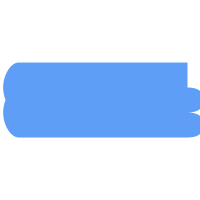

In [23]:
# NOT WHAT WE WANT
from IPython.display import SVG, display, HTML
import cairosvg
from IPython.display import Image
import io

# print(sub_df.loc[0, 'svg'])
display(SVG(pred_svg))

### Load Saved Model in Drive

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
from unsloth import FastLanguageModel

# LOading Model
model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name='/content/drive/MyDrive/Colab Notebooks/DL/content/qwen2b_svg_lora',
    model_name=CONFIG['output_dir'],
    max_seq_length=CONFIG["max_seq_length"],
    dtype=None,
    load_in_4bit=True,
)


FastLanguageModel.for_inference(model)
model.eval()

==((====))==  Unsloth 2026.4.1: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3VLForConditionalGeneration(
      (model): Qwen3VLModel(
        (visual): Qwen3VLVisionModel(
          (patch_embed): Qwen3VLVisionPatchEmbed(
            (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
          )
          (pos_embed): Embedding(2304, 1024)
          (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-23): 24 x Qwen3VLVisionBlock(
              (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
              (attn): Qwen3VLVisionAttention(
                (qkv): Linear(in_features=1024, out_features=3072, bias=True)
                (proj): Linear(in_features=1024, out_features=1024, bias=True)
              )
              (mlp): Qwen3VLVisionMLP(
                (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
               

In [26]:
import gc
gc.collect()
# Clear PyTorch's GPU memory cache
torch.cuda.empty_cache()

import tensorflow as tf
tf.keras.backend.clear_session()

# del model
# del tokenizer


In [27]:
from tqdm import tqdm

def generate_svg_batch(all_prompts:list[str], max_new_tokens=CONFIG['max_seq_length'], batchsize=8):
    all_svgs = []

    for p_i in tqdm(range(0, len(all_prompts), batchsize), desc='Svg To Prompts'):
        print('Converting Prompt')
        chat_texts = [
            "<|im_start|>system\n"
            f"{SYSTEM_PROMPT}<|im_end|>\n"
            "<|im_start|>user\n"
            f"{prompt}<|im_end|>\n"
            "<|im_start|>assistant\n" for prompt in all_prompts[p_i : p_i + batchsize]
        ]

        print('Running Tokenizer')
        inputs = tokenizer(
            text=chat_texts,
            padding=True,
            return_tensors="pt",
            padding_side='left', # TODO: UNDERSTAND PADDING EFFECT
        ).to(model.device)

        print('Running Model')
        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.05,
            )
            # print(output_ids.shape)
        output_ids = output_ids.cpu() # Move output to cpu for tokenizer

        print('Tokenizer Decode')
        decoded_prompts = tokenizer.decode(output_ids, skip_special_tokens=True)

        decoded_prompts = [decoded.replace('<svg>', '(omit-svg)', 1) for decoded in decoded_prompts]
        # Done due to <svg> inclusion in the prompt, which causes regex parsing errors, and then defaults to default svg output
        # May be ommited, if there is a different model used that purely returns svg code

        for i in range(len(decoded_prompts)):
            svg = extract_svg(decoded_prompts[i])
            # print(f"extracted svg len {len(svg)}")
            if not is_valid_svg(svg):
                svg = fallback_svg( 'NULL' )
                # print(f"fallback svg len {len(svg)}")
            all_svgs.append(svg)

    return all_svgs

In [28]:
TEST_PROMPTS_PATH = "./dataset/test.csv"
SUBMISSION_PATH = f"./dataset/sample_submission_ABLATION_{CONFIG['param_module']}.csv"

test_df = pd.read_csv(TEST_PROMPTS_PATH)
# test_df = test_df.iloc[0:10]

rows = []
invalid_count = 0
t0 = time.time()

all_svgs = generate_svg_batch(
    test_df['prompt'].tolist(),
    batchsize=100
)
print(len(all_svgs))
print(all_svgs)
print(test_df.shape)
for i in range(len(all_svgs)):
    rows.append({"id": test_df.loc[i, "id"], "svg": all_svgs[i]})

sub_df = pd.DataFrame(rows)
sub_df.to_csv(SUBMISSION_PATH, index=False)

elapsed_min = (time.time() - t0) / 60
print(f"Saved: {SUBMISSION_PATH}")
print(f"Rows: {len(sub_df)}")
print(f"Invalid/fallback count: {invalid_count}")
print(f"Runtime (minutes): {elapsed_min:.2f}")
sub_df.head()

Svg To Prompts:   0%|          | 0/10 [00:00<?, ?it/s]

Converting Prompt
Running Tokenizer
Running Model


Svg To Prompts:  10%|█         | 1/10 [05:52<52:49, 352.13s/it]

Tokenizer Decode
Converting Prompt
Running Tokenizer
Running Model


Svg To Prompts:  20%|██        | 2/10 [11:21<45:10, 338.86s/it]

...

Svg To Prompts:  90%|█████████ | 9/10 [50:16<05:34, 334.79s/it]

Tokenizer Decode
Converting Prompt
Running Tokenizer
Running Model


Svg To Prompts: 100%|██████████| 10/10 [55:52<00:00, 335.27s/it]

Tokenizer Decode
1000
['<svg xmlns="http://www.w3.org/2000/svg" width="256" height="256" viewBox="0 0 256 256"><rect x="0" y="0" width="256" height="256" fill="white"/><circle cx="128" cy="128" r="64" fill="black"/></svg>', '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#000000" fill-opacity="1.0"  filling="0" d="M141.66700744628906 158.33300018310547 L58.33300018310547 158.33300018310547 A1.6669998168945312 1.6669998168945312 0.0 0 1 56.66699981689453 156.66700744628906 L56.66699981689453 33.33300018310547 A1.6669998168945312 1.6669998168945312 0.0 0 1 58.33300018310547 31.66699981689453 L141.66700744628906 31.66699981689453 A1.6669998168945312 1.6669998168945312 0.0 0 1 143.33300018310547 33.33300018310547 L143.33300018310547 156.66700744628906 A1.6669998168945312 1.6669998168945312 0.0 0 1 141.66700744628906 158.33300018310547 Z M108.33300018310547 158.33300018310547 L91.66699981689453 158.33300018310547 L91.666999

,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
1,6eede943219547c22ac56085027d33cc,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,ea045c7a247166f061ce504d9b7ccaab,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,8fe82f3af89e487b31236ca829c3f071,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
4,600464e4d92c75338462271a09b3f176,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


In [29]:
sub_df.head(10)

,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
1,6eede943219547c22ac56085027d33cc,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
2,ea045c7a247166f061ce504d9b7ccaab,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
3,8fe82f3af89e487b31236ca829c3f071,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
4,600464e4d92c75338462271a09b3f176,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
5,9e831fb6831745f4d15156b7a95e4f92,"<svg xmlns=""http://www.w3.org/2000/svg"" width=..."
6,8cbefcd53fd5dfa2cbe1b374356ed709,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."
7,625181a2-600d-4db5-83c6-1a34676eb0dc,"<svg height=""128"" viewBox=""-3 -3 32 32"" width=..."
8,8ba1bd7c-211c-43b0-a4aa-0e6e33c92486,"<svg fill=""none"" height=""128"" viewBox=""0 0 24 ..."
9,4e56e508270eb0d02291927638d3c685,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBo..."


In [30]:
test_df['prompt'].head(10), test_df['prompt'].iloc[6]

(0    firewood stack cut logs wood with leaf illustr...
 1    The image shows five horizontal lines of varyi...
 2    A stylized icon depicting a curved arrow withi...
 3    The image contains black geometric shapes agai...
 4    The image shows a single dark gray triangle po...
 5    An orange hexagon with the number '13' inside it.
 6    The image features a simple, blue outlined cam...
 7    The image is a black and white representation ...
 8    A pair of men's underwear with a contour desig...
 9    A single, dark gray outline of an abstract sha...
 Name: prompt, dtype: object,
 'The image features a simple, blue outlined camera icon centered within a white circular background.')

## Save Results

In [31]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# !cp -r "/content/qwen2b_svg_lora" "/content/drive/MyDrive/Colab_Notebooks/DL"


In [33]:
# !cp -r "./dataset/sample_submission.csv" "/content/drive/MyDrive/Colab Notebooks/DL"

In [34]:
# return_val = subprocess.run(['cp', '-r', SUBMISSION_PATH, "/content/drive/MyDrive/Colab Notebooks/DL/"]) # WMZ
return_val = subprocess.run(['cp', '-r', SUBMISSION_PATH, "/content/drive/MyDrive/Colab_Notebooks/DL/"]) # WZ
print(return_val)
print(return_val.stdout)
print(return_val.stderr)

CompletedProcess(args=['cp', '-r', './dataset/sample_submission_ABLATION_NONE.csv', '/content/drive/MyDrive/Colab_Notebooks/DL/'], returncode=0)
None
None


In [35]:
import os
print(os.path.exists('/content/drive/MyDrive/Colab_Notebooks/DL/'))

True


## Notes

- Keep a fixed seed, runtime logs, and invalid-generation counts (required by `contest_docs/05`).
- If you use Kaggle-packaged datasets (`svg-train-public`, `svg-test-public-prompts`, `svg-utils`), swap paths into the loading cells.
- For stricter alignment with Unsloth templates, copy the latest prompt-formatting snippets from the official Qwen3.5-2B notebook linked above.

In [36]:
# from google.colab import runtime
# runtime.unassign()
